In [1]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch
## 2026.03.19 Train and using NCRT_train.ipynb
## 2026.03.23 Adjust file name and path, then adjust model to use level1 and level2, make model_train_validate.ipynb

In [3]:
import sys
import os
import importlib
import pandas as pd
from pathlib import Path

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg/'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
import base
import plot
import model
## Impost：Force reload base.py
importlib.reload(base)  
importlib.reload(plot)  
importlib.reload(model)

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    load_cell_pixcoords,load_hist_embeddings,
    match_hist2cell_matrix,
    make_PCF2HE2StarDist_alignment,
    save_hce_validation_metrics,
    split_train_test,
    loader_train_test
    
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram,
    plot_confusion_matrix,
    plot_level1_spatial_distribution,
    plot_per_class_f1,
)

from model import (
    build_mlp_classifier,
    get_best_checkpoint_path,
    train_and_save_model,
    infer_input_dim_and_num_classes,
    mode_validation,
    load_model_for_predict,
    train_and_save_model_from_split,
    mode_validation_from_split
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
os.chdir(f'{path}Hist2Pheno/data/CODEX/ESCC')
therapy_data = 'NCRT'
therapy_model = f'{therapy_data}_project_tumor1'
segment_data1 = f'{therapy_data}_project - seg 1-14'
segment_data2 = f'{therapy_data}_project - seg 15-28'
export_data = 'export'
save_result = 'result'

stardist_data = 'StarDist_Segment'
transfer_data = 'he_cell_coords'
qupath_corner = 'QupathCorners'

Successfully reloaded functions from base.py
openslide: False, tifffile: True


In [4]:
## CUDA/CPU sanity check for training setup
import os
import sys
import torch

print(sys.executable)
print(
    f"torch {torch.__version__} | built with CUDA: {torch.version.cuda} | "
    f"cuda.is_available: {torch.cuda.is_available()}"
)

if torch.cuda.is_available():
    device = torch.device("cuda")
    # Reproducibility-first: use deterministic cuDNN settings.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    amp_scaler = torch.amp.GradScaler("cuda")  # AMP only on CUDA
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    allow_cpu = os.environ.get("NCRT_ALLOW_CPU_TRAIN", "").strip().lower() in ("1", "true", "yes")
    if allow_cpu:
        device, amp_scaler = torch.device("cpu"), None
        print("WARNING: CUDA unavailable, training on CPU (set NCRT_ALLOW_CPU_TRAIN=1).")
    else:
        raise RuntimeError(
            "CUDA unavailable. Please use a CUDA-enabled PyTorch build, "
            "or set NCRT_ALLOW_CPU_TRAIN=1 to run on CPU."
        )

print(f"device: {device}" + (f" | {torch.cuda.get_device_name(0)}" if device.type == "cuda" else ""))



## Reproducibility setup (run this first after kernel restart)
import os
import random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
# Needed by CUDA for deterministic GEMM on some ops.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Enforce deterministic behavior (may reduce speed).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

print(f"Reproducibility configured with SEED={SEED}")

/ssd2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda | NVIDIA RTX PRO 6000 Blackwell Server Edition
Reproducibility configured with SEED=42


## Cell Type Classification Model

In [5]:
## Match embeddings with celltype data by coordinates
cell_coords_path = f'{path}Hist2Pheno/data/CODEX/ESCC/he_cell_coords/{therapy_data}_CellPixCoords_tumor1.csv'
hist_embedding_dir = Path(f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/ImgEmbeddings_tumor1/sc_pth_16_16')
matched_features_path = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/matched_features_tumor1.npz'

# Coordinate matching tolerance in pixels (float supported).
# base.py now handles optional `celltype_level1` automatically.
match_tolerance = 1.0
X, y, y_level1, X_coords_matched = match_hist2cell_matrix(
    cell_coords_path,
    hist_embedding_dir,
    matched_features_path,
    coord_cols=('X_pix_HE', 'Y_pix_HE'),
    tolerance=match_tolerance,
)

Loading celltype Ground Truth ...
  Loaded 80303 cells
  Cell types: 40 unique types

  ✓ matched_features cache found; skipping .pth directory load.
Loading pre-saved matched data...
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1.npz
  X shape: (80303, 384)
  y shape: (80303,)
  Number of classes: 40
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (80303, 2)


In [6]:
result = split_train_test(X, y, y_level1)

# Keep only widely used metadata as top-level variables.
class_names = result["class_names"]
class_names_level1 = result["class_names_level1"]
le_level2 = result["le_level2"]
le_level1 = result["le_level1"]
scaler = result["scaler"]


Train/Test split:
  Training set: 56211 samples
  Test set: 24091 samples
  Feature dimension: 384
  Level2 classes: 39
  Level1 classes: 7
  Features standardized


In [ ]:
loaders = loader_train_test(result, seed=SEED)

train_loader = loaders["train_loader"]
val_loader = loaders["val_loader"]
val_loader_eval = loaders["val_loader_eval"]
train_dataset = loaders["train_dataset"]
val_dataset = loaders["val_dataset"]

## downstream args for model.py
X_train_scaled = loaders["X_train_scaled"]
y_train_encoded = loaders["y_train_encoded"]
y_test_encoded = loaders["y_test_encoded"]
y_train_level1_encoded = loaders["y_train_level1_encoded"]
y_test_level1_encoded = loaders["y_test_level1_encoded"]
y_encoded_f = loaders["y_encoded_f"]
y_level1_encoded_f = loaders["y_level1_encoded_f"]

## MLP classifier

In [12]:
## Path to save the best model
save_bestmodel_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{therapy_model}/best_mlp_gpu.pt"

best_weighted_f1, best_macro_f1, best_epoch = train_and_save_model_from_split(
    device=device,
    loaders=loaders,
    result=result,
    evaluate=evaluate,
    save_bestmodel_path=save_bestmodel_path,
    class_names=class_names if 'class_names' in globals() else None,
    hce_lambda=0.5,
    patience=10,
    max_epochs=50,
)

Model configuration:
  Input dimension: 384
  Number of level2 classes: 39
  Number of level1 classes: 7
Model initialized on cuda
Model parameters: 1,063,975
HCE enabled: total_loss = CE(level2) + 0.500 * CE(level1)
Starting training with HCE...


/ssd2/users/lingyu/conda_envs/SeededNTM/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(



Epoch 1/50 (1.56s, LR: 0.000132)
  Train HCE Loss: 6.9711
  CE(level2): 5.7480, CE(level1): 2.4461
  Val L2 Accuracy: 0.2441
  Val L2 Macro-F1: 0.0651
  Val L2 Weighted-F1: 0.2303
  Val L1 Accuracy: 0.4231
  Val L1 Macro-F1: 0.3711
  Val L1 Weighted-F1: 0.4136
  ✓ Best model saved (Weighted-F1: 0.2303, Macro-F1: 0.0651)

Epoch 2/50 (1.15s, LR: 0.000374)
  Train HCE Loss: 5.3082
  CE(level2): 4.4361, CE(level1): 1.7442
  Val L2 Accuracy: 0.2881
  Val L2 Macro-F1: 0.0856
  Val L2 Weighted-F1: 0.2751
  Val L1 Accuracy: 0.4691
  Val L1 Macro-F1: 0.4202
  Val L1 Weighted-F1: 0.4623
  ✓ Best model saved (Weighted-F1: 0.2751, Macro-F1: 0.0856)

Epoch 3/50 (1.20s, LR: 0.000671)
  Train HCE Loss: 4.5100
  CE(level2): 3.7444, CE(level1): 1.5310
  Val L2 Accuracy: 0.3041
  Val L2 Macro-F1: 0.0901
  Val L2 Weighted-F1: 0.2835
  Val L1 Accuracy: 0.4878
  Val L1 Macro-F1: 0.4391
  Val L1 Weighted-F1: 0.4804
  ✓ Best model saved (Weighted-F1: 0.2835, Macro-F1: 0.0901)

Epoch 4/50 (1.27s, LR: 0.00091

In [ ]:
## Validate model on validation dataset (both level2 and level1)
(
    model,
    input_dim,
    val_acc,
    val_macro_f1,
    val_weighted_f1,
    val_preds,
    val_labels,
    val_level1_acc,
    val_level1_macro_f1,
    val_level1_weighted_f1,
    val_preds_level1,
    val_labels_level1,
) = mode_validation_from_split(
    device=device,
    path=path,
    therapy_data=therapy_data,
    loaders=loaders,
    result=result,
    class_names=class_names if 'class_names' in globals() else None,
    class_names_level1=class_names_level1 if 'class_names_level1' in globals() else None,
    therapy_model=therapy_model if 'therapy_model' in globals() else None,
)


Validation Performance (Level2, best checkpoint):
  Accuracy: 0.4032
  Macro F1-score: 0.1472
  Weighted F1-score: 0.3893

Detailed Classification Report (Level2):
                       precision    recall  f1-score   support

              B_other       0.05      0.12      0.07       128
      B_proliferating       0.00      0.00      0.00        18
          Bm_switched       0.01      0.04      0.02       113
        Bm_unswitched       0.04      0.11      0.06       106
                   Bn       0.00      0.00      0.00        21
               CAF_ap       0.02      0.16      0.03        67
            CAF_other       0.22      0.12      0.15      1254
              CD4_Tcm       0.00      0.00      0.00         1
              CD4_Tem       0.01      0.05      0.02        82
              CD4_Tex       0.11      0.07      0.08       751
               CD4_Tn       0.00      0.00      0.00        16
             CD8_Teff       0.08      0.19      0.11       217
              C

Computing confusion matrix...
Figure saved to NCRT/result/conf_matrix_tumor1_level2_hce.pdf


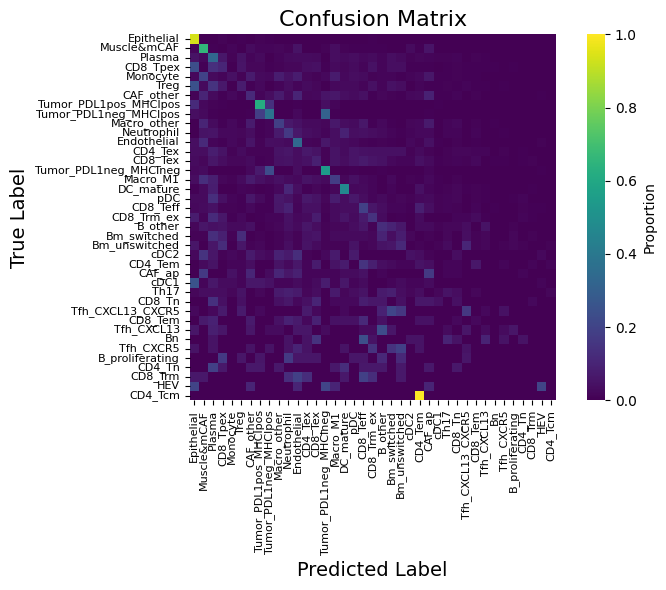

Computing confusion matrix...
Figure saved to NCRT/result/conf_matrix_tumor1_level1_hce.pdf


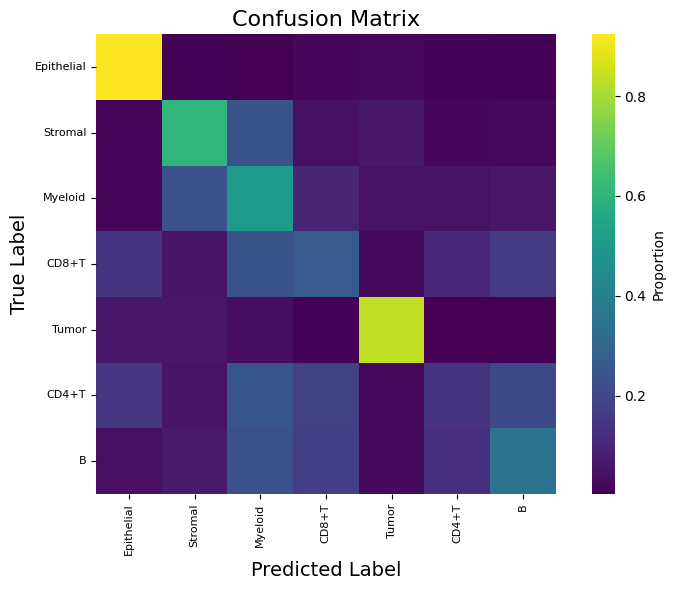

In [14]:
# Level2 confusion matrix
plot_confusion_matrix(
    val_labels,
    val_preds,
    class_names,
    save_path=f'{therapy_data}/{save_result}/conf_matrix_tumor1_level2_hce.pdf',
)

# Level1 confusion matrix
plot_confusion_matrix(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    save_path=f'{therapy_data}/{save_result}/conf_matrix_tumor1_level1_hce.pdf',
)

In [15]:
## Save validation metrics
metrics_csv_path = f"{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/hce_lambda_validation_metrics.csv"

hce_lambda_used = hce_lambda if 'hce_lambda' in globals() else 0.5
metrics_df, combined_df = save_hce_validation_metrics(
    val_acc=val_acc,
    val_macro_f1=val_macro_f1,
    val_weighted_f1=val_weighted_f1,
    val_level1_acc=val_level1_acc,
    val_level1_macro_f1=val_level1_macro_f1,
    val_level1_weighted_f1=val_level1_weighted_f1,
    class_names=class_names if 'class_names' in globals() else None,
    class_names_level1=class_names_level1 if 'class_names_level1' in globals() else None,
    best_epoch=best_epoch if 'best_epoch' in globals() else None,
    hce_lambda=hce_lambda_used,
    therapy_data=therapy_data,
    metrics_csv_path=metrics_csv_path
)

Current run metrics:
             timestamp therapy_data  best_epoch  hce_lambda  val_l2_accuracy  \
0  2026-03-23 23:20:59         NCRT          49         0.5         0.403221   

   val_l2_macro_f1  val_l2_weighted_f1  val_l1_accuracy  val_l1_macro_f1  \
0         0.147225            0.389346         0.569134         0.508784   

   val_l1_weighted_f1  num_l2_classes  num_l1_classes  
0            0.552447              39               7  

Saved comparison table to: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/result/hce_lambda_validation_metrics.csv
Total rows: 6


Visualizing per-class performance...
  ✓ Computed metrics for 39 classes
Figure saved to NCRT/result/f1_per_class_tumor1_level2_hce.pdf


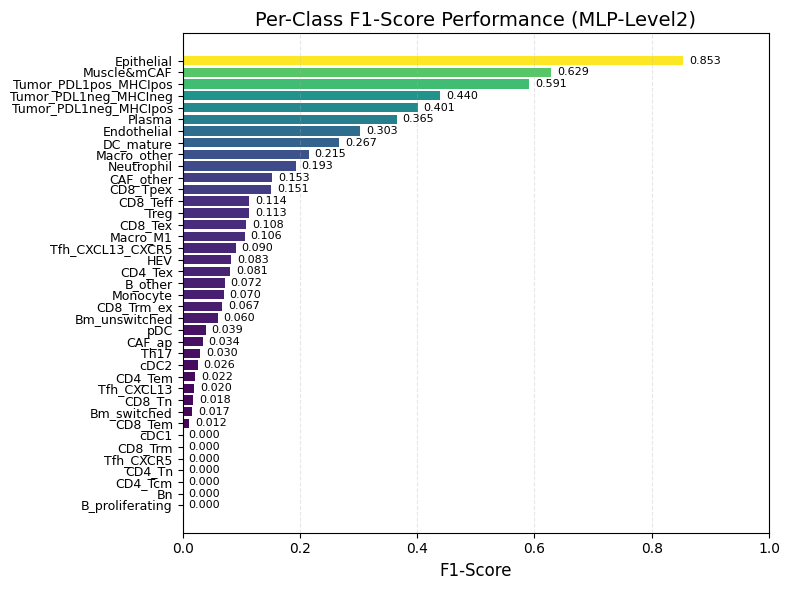


Model Summary:
  Device: cuda
  Training samples: 56211
  Test samples: 24091
  Total classes (before filtering): 39
  Actual classes in test set: 39
  Feature dimension: 384
  Model parameters: 1,063,975
  Best epoch: 49
  Test Accuracy: 0.4032
  Test Macro F1: 0.1472
  Test Weighted F1: 0.3893
Visualizing per-class performance...
  ✓ Computed metrics for 7 classes
Figure saved to NCRT/result/f1_per_class_tumor1_level1_hce.pdf


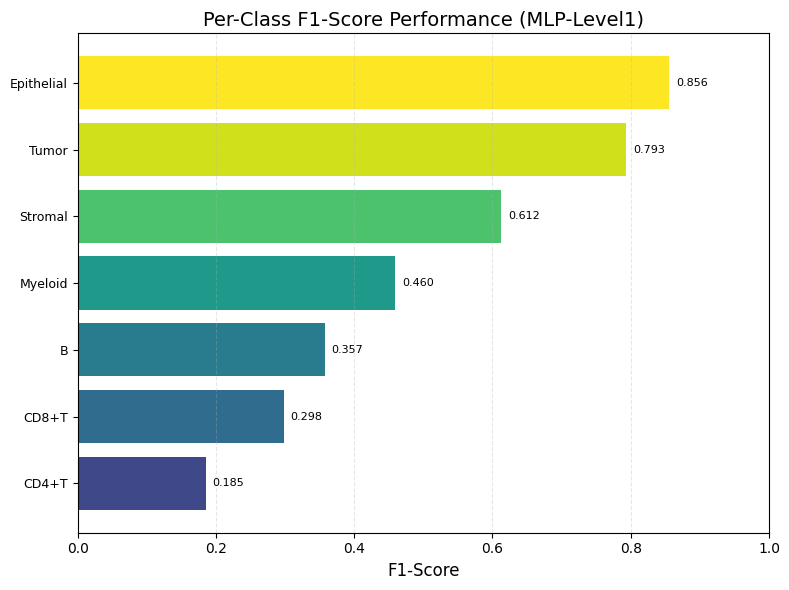


Model Summary:
  Device: cuda
  Training samples: 56211
  Test samples: 24091
  Total classes (before filtering): 7
  Actual classes in test set: 7
  Feature dimension: 384
  Model parameters: 1,063,975
  Best epoch: 49
  Test Accuracy: 0.5691
  Test Macro F1: 0.5088
  Test Weighted F1: 0.5524


In [16]:
# Per-class F1 for level2
metrics_df_level2 = plot_per_class_f1(
    val_labels,
    val_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_acc,
    test_macro_f1=val_macro_f1,
    test_weighted_f1=val_weighted_f1,
    model_name="MLP-Level2",
    save_path=f'{therapy_data}/{save_result}/f1_per_class_tumor1_level2_hce.pdf',
)

# Per-class F1 for level1
metrics_df_level1 = plot_per_class_f1(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_level1_acc,
    test_macro_f1=val_level1_macro_f1,
    test_weighted_f1=val_level1_weighted_f1,
    model_name="MLP-Level1",
    save_path=f'{therapy_data}/{save_result}/f1_per_class_tumor1_level1_hce.pdf',
)

  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1.npz: (80303, 384)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/NCRT/NCRT_project_tumor1/matched_features_tumor1.npz: (80303,), dtype: <U21
  ⚠ Note: Labels will be used for evaluation. If encoding mismatch occurs, set prediction_only=True.
  ⚠ y contains string labels. Encoding to integers...
  ⚠ Warning: New LabelEncoder may produce different encoding than training!
  ⚠ This can cause label mismatch if data has different classes than training.
  ✓ Encoded y to integers: (80303,), dtype: int64
  ⚠ Encoded labels have 40 unique classes (0-39)
  ⚠ Model expects unknown classes
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (80303, 384)
  y_all_encoded shape: (80303,)
  ✓ Final y_all_encoded dtype: int64
X_all_scaled:  (80303, 384)
y_all_encoded:  (80303,)
  ⚠ Large dataset detected (80303 samples).

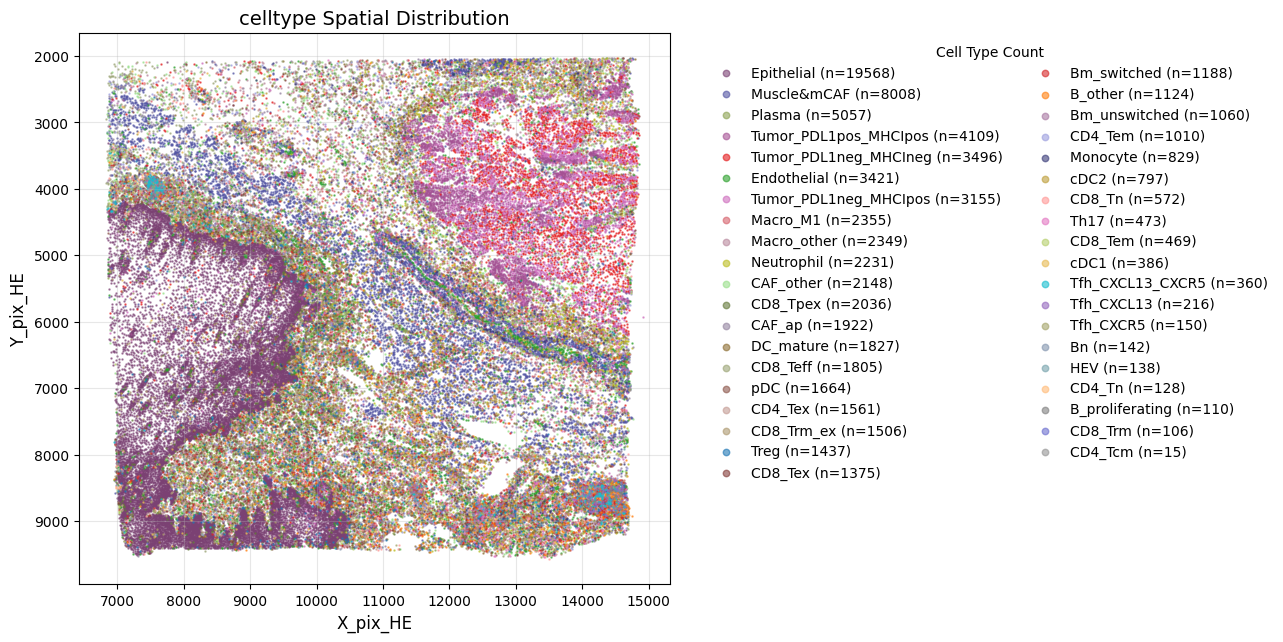

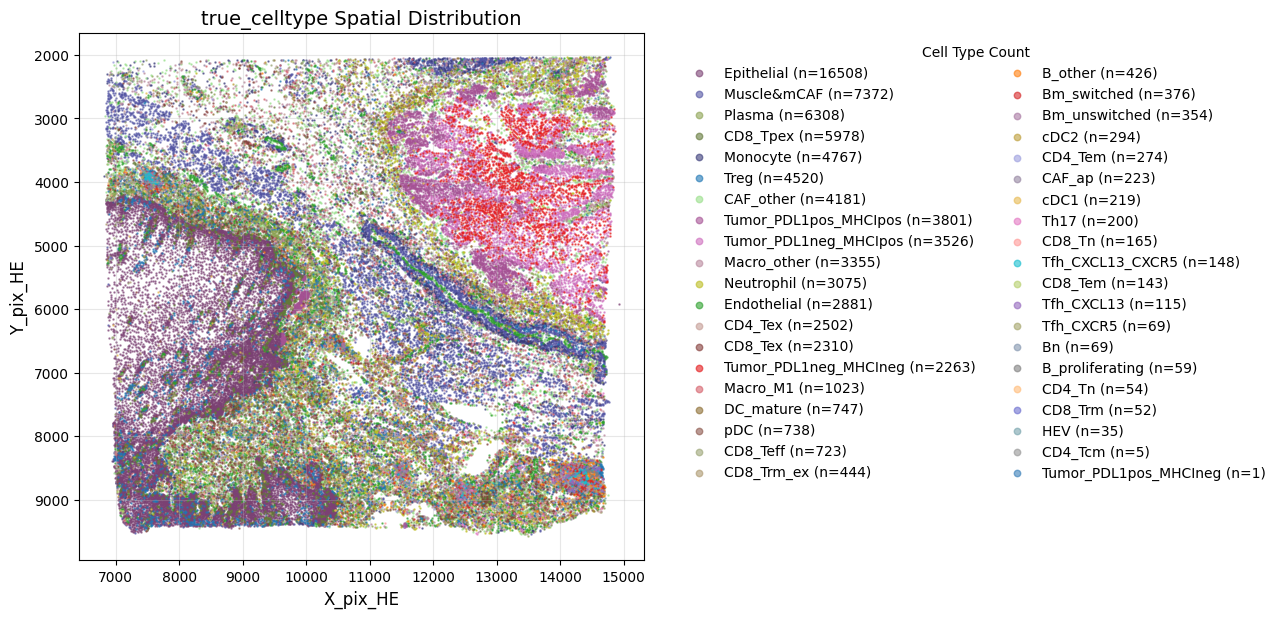

In [17]:
## Evaluate on all data and plot spatial distribution
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path=matched_features_path,
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=val_loader if 'val_loader' in globals() else None,
    X=X if 'X' in globals() else None,
    y=y if 'y' in globals() else None,
    y_encoded=y_encoded if 'y_encoded' in globals() else None,
    X_train=X_train if 'X_train' in globals() else None,
    X_train_scaled=X_train_scaled if 'X_train_scaled' in globals() else None,
    X_test_scaled=X_test_scaled if 'X_test_scaled' in globals() else None,
    y_train_encoded=y_train_encoded if 'y_train_encoded' in globals() else None,
    y_test_encoded=y_test_encoded if 'y_test_encoded' in globals() else None,
    min_samples_per_class=min_samples_per_class if 'min_samples_per_class' in globals() else 29,
    X_coords_matched=X_coords_matched if 'X_coords_matched' in globals() else None,
    celltype_pred_dir = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/celltype_valid_tumor1_level2_hce.jpg',
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if 'celltype_pixel_NCRT_tumor1' in globals() else None
)

Number of valid data points: 80303
Number of cell types: 7
Number of valid data points: 80303
Number of cell types: 7


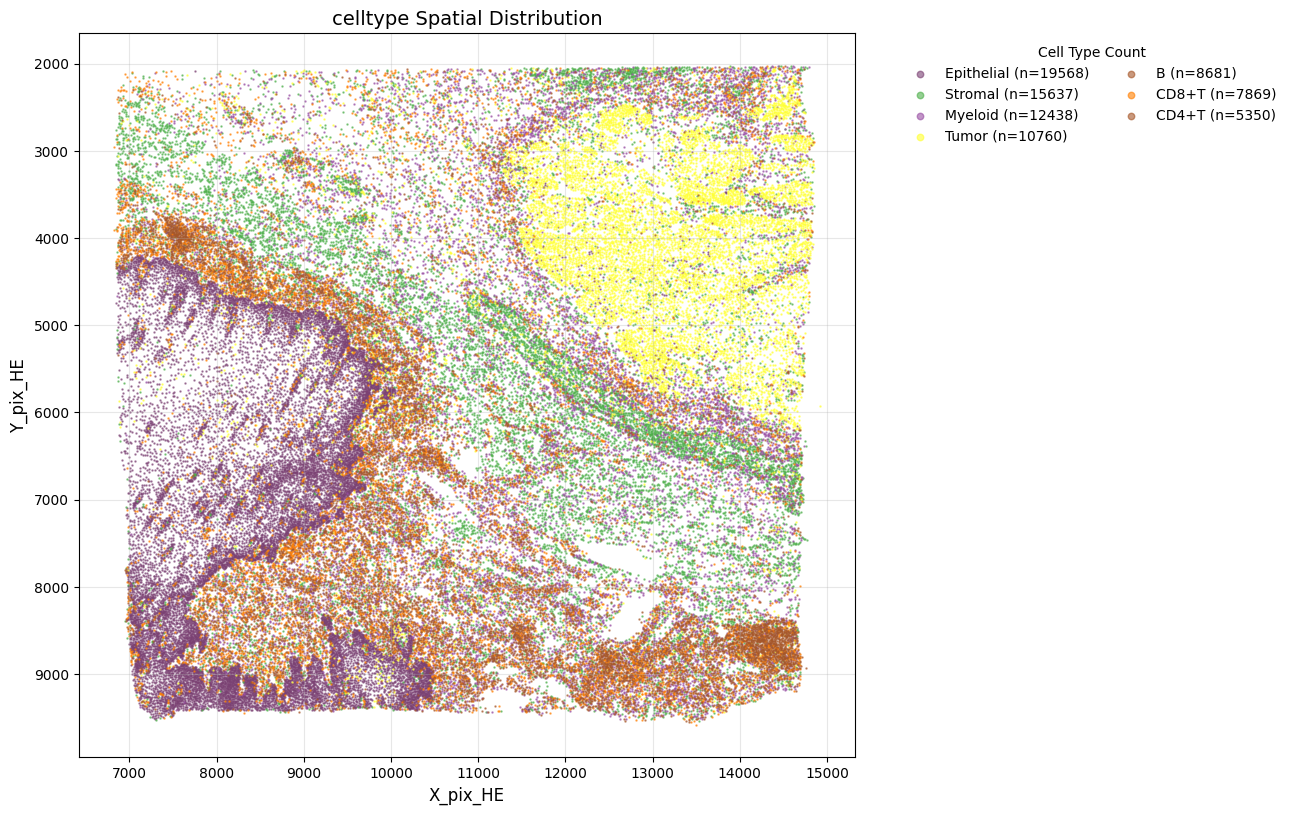

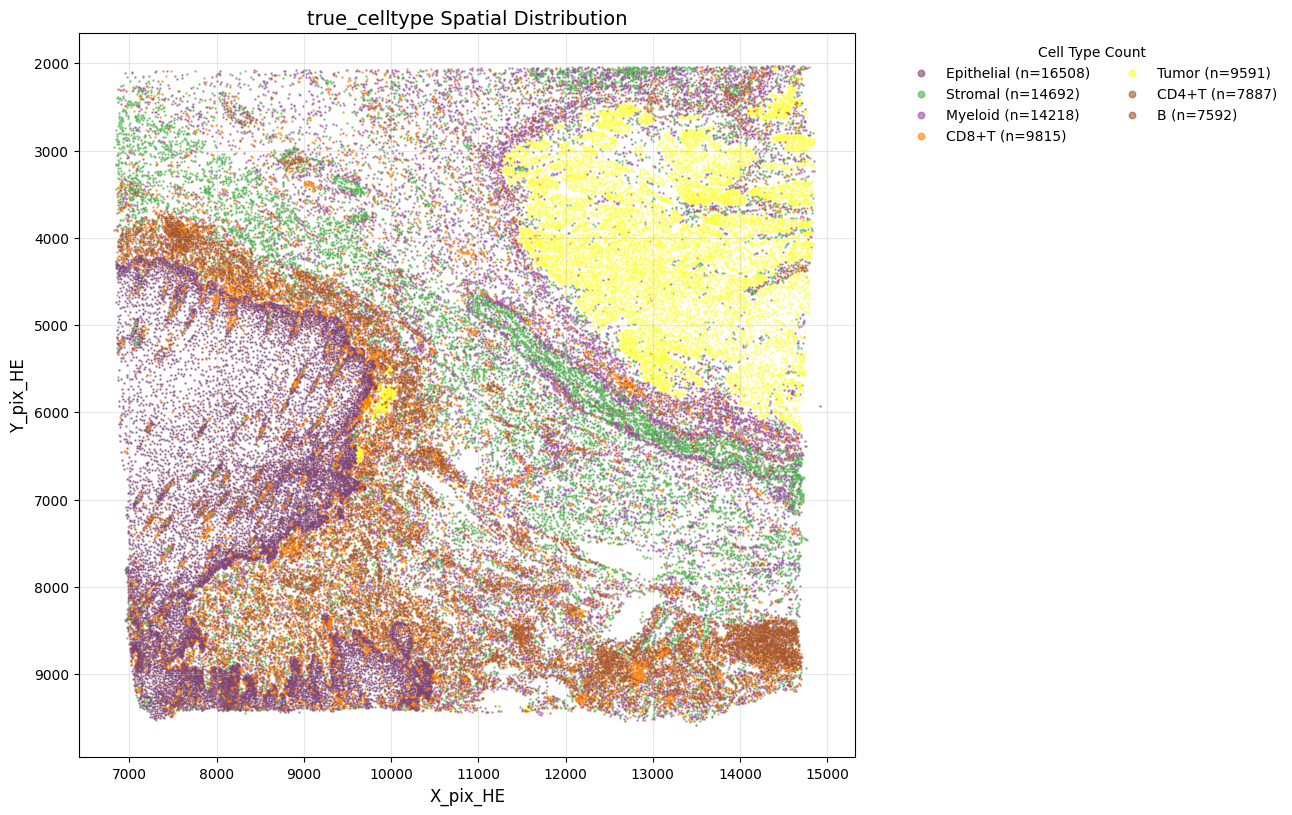

In [18]:
save_path_pred = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/celltype_valid_tumor1_level1_hce.jpg'
save_path_true = f'{path}Hist2Pheno/data/CODEX/ESCC/{therapy_data}/{save_result}/celltype_true_tumor1_level1_hce.jpg'
plot_level1_spatial_distribution(
    matched_features_path=matched_features_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=save_path_pred,
    save_path_true=save_path_true
)